# Inverse Reinforcement Learning for Execution

**Chapter 21: Reinforcement Learning for Execution and Hedging**

## Purpose

Every notebook before this one was handed an objective and asked for a policy.
This one runs the arrow the other way: given a record of what a trader did,
what objective would make those actions sensible?

The question is worth asking because the record is often all there is. A desk
can see its own historical fills, or a counterparty's, without any statement
of what the schedule behind them was for. Two families of answer are compared
here on the same demonstrations. **Behaviour cloning** skips the question and
fits the actions directly, which produces a policy and no explanation.
**Inverse reinforcement learning** fits a reward, which produces an
explanation and, through it, a policy that can in principle be transferred to
a market where the original schedule would not apply.

The demonstrations come from a rule whose objective is already known - TWAP -
so the inferred reward can be read against the truth rather than admired.

## Learning objectives

After working through this notebook you will be able to:

- Fit a behaviour clone to state-action pairs from demonstrations, split so
  that no two states from one episode straddle the training boundary, and say
  why the clone's error grows once it starts driving the environment itself.
- Write down a linear reward over execution features and fit it by maximum
  entropy over a fixed bank of candidate trajectories, including the partition
  function that makes the objective a likelihood.
- Fit the same reward by matching expert feature expectations against rollouts
  of the current policy, and say which of the two procedures has an objective
  it is descending and which does not.
- Read a set of inferred reward weights for what they are: a description of
  what covaries with the demonstrated behaviour, under a parameterisation that
  does not identify a unique reward.

## Book reference

Section 21.7, *Inverse reinforcement learning - Learning from observed
behavior*.

## Prerequisites

- `02_optimal_execution_ppo`, for implementation shortfall, TWAP and the
  pacing action this notebook's demonstrations are recorded in.
- `rl_environments.ExecutionEnv` and `rl_calibration.CryptoMarketCalibrator`.

In [1]:
"""Inverse reinforcement learning for execution - infer a reward from demonstrated trades."""

import warnings

import numpy as np
import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display
from plotly.subplots import make_subplots
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor

# Deprecation notices from these dependencies repeat on every environment
# construction and report nothing about this run. Convergence, overflow and
# invalid-value warnings stay visible: they report conditions results depend on.
warnings.filterwarnings("ignore", category=DeprecationWarning, module="gymnasium")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="sklearn")

from rl_calibration import CryptoMarketCalibrator
from rl_environments import ExecutionEnv

import utils  # noqa: F401  - sets the Plotly renderer so figures carry a static PNG
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_plotly_with_alt

In [2]:
TOTAL_SHARES = 5_000  # size of the parent order the expert liquidates
EXECUTION_HORIZON = 30  # steps available to complete it
N_EXPERT_TRAJECTORIES = 200  # demonstrations recorded from the expert rule
TRAIN_FRACTION = 0.8  # share of demonstrations used to fit; the rest are held back
BC_EPOCHS = 500  # optimiser passes for the neural behaviour clone
IRL_ITERATIONS = 100  # gradient-ascent steps on the maximum-entropy likelihood
N_CANDIDATE_TRAJECTORIES = 400  # proposals in the fixed bank the partition sums over
MAXENT_L2 = 0.05  # ridge penalty on the reward weights
FEATURE_MATCH_ITERATIONS = 50  # iterations of the feature-expectation baseline
N_FEATURE_MATCH_TRAJECTORIES = 50  # rollouts per iteration of that baseline
N_EVALUATION_EPISODES = 200  # episodes every policy is scored on
SEED = 42

In [3]:
set_global_seeds(SEED)

### What the settings decide

`N_CANDIDATE_TRAJECTORIES` is the one that decides what the maximum-entropy
fit can mean. Exact maximum-entropy inverse reinforcement learning normalises
over every trajectory the environment admits, which in a continuous action
space is uncountable. The implementation here replaces that sum with a fixed
bank of proposals, so the likelihood it maximises is a likelihood over that
bank. A wider bank is a better approximation and a more expensive one; the
bank stays fixed across iterations so that the objective does not move while
it is being climbed.

In [4]:
display(
    Markdown(f"""
- **Demonstrations**: {N_EXPERT_TRAJECTORIES} episodes of the expert rule liquidating
  {TOTAL_SHARES:,} shares over {EXECUTION_HORIZON} steps.
- **Split**: the first {TRAIN_FRACTION:.0%} of episodes fit both the clone and the reward;
  the rest are held back. Episodes are split whole, so no two states from one episode
  land on opposite sides of the boundary.
- **Maximum-entropy bank**: {N_CANDIDATE_TRAJECTORIES} proposal trajectories plus the
  training demonstrations, fixed before fitting starts.
- **Feature-expectation baseline**: {FEATURE_MATCH_ITERATIONS} iterations of
  {N_FEATURE_MATCH_TRAJECTORIES} fresh rollouts each, redrawn under the current weights.
- **Evaluation**: {N_EVALUATION_EPISODES} episodes, the same seeds for every policy.
""")
)


- **Demonstrations**: 200 episodes of the expert rule liquidating
  5,000 shares over 30 steps.
- **Split**: the first 80% of episodes fit both the clone and the reward;
  the rest are held back. Episodes are split whole, so no two states from one episode
  land on opposite sides of the boundary.
- **Maximum-entropy bank**: 400 proposal trajectories plus the
  training demonstrations, fixed before fitting starts.
- **Feature-expectation baseline**: 50 iterations of
  50 fresh rollouts each, redrawn under the current weights.
- **Evaluation**: 200 episodes, the same seeds for every policy.


## 1. The demonstrations

The expert is **TWAP**, which sells the same quantity at every step. It is a
deliberate choice of demonstrator: it is deterministic, so the demonstrations
carry no policy noise to be confused with structure, and its objective is
already known, so the inferred reward can be checked rather than believed.

What TWAP optimises is worth stating precisely, because it is the thing the
inference is trying to recover. Under the Almgren-Chriss decomposition, an
execution schedule trades impact cost against timing risk: trading faster
pushes the price against the order, trading slower leaves the unsold remainder
exposed to whatever the price does next. TWAP is the schedule at the
risk-neutral end of that trade-off. It spreads the order out to keep each
step's participation, and so its impact, as small as the horizon allows, and
it accepts the full timing risk that spreading out creates. It conditions on
nothing else: not the spread, not the depth, not the volatility, all of which
the environment varies and the observation reports.

That last point is what makes this a test rather than a demonstration. A
reward inferred from these paths that puts weight on depth or volatility has
found a correlate, not a preference.

In [5]:
# Calibrate environment from real data
print("Calibrating simulation from real crypto data...")
calibrator = CryptoMarketCalibrator("BTCUSDT")
cal_params = calibrator.get_execution_env_params()

# Create environment
INITIAL_PRICE = 100.0

env = ExecutionEnv(
    total_shares=TOTAL_SHARES,
    horizon=EXECUTION_HORIZON,
    initial_price=INITIAL_PRICE,
    cal_params=cal_params,
)

Calibrating simulation from real crypto data...


### Expert Policy (TWAP)

Our "expert" targets one equal schedule slice at each step. The environment
exposes actions as normalized pace controls, so the policy converts its target
share count through the environment API rather than treating the action as an
inventory fraction.

In [6]:
def twap_policy(obs: np.ndarray, env: ExecutionEnv) -> float:
    """Return the normalized pace action for the environment's TWAP slice."""
    if obs[0] <= 0:
        return 0.0
    target_shares = env.reference_trade_size()
    return float(env.target_shares_to_action(target_shares)[0])

### Collect Expert Demonstrations

Run the TWAP expert for multiple episodes, collecting state-action pairs
as training data for both behavior cloning and IRL.

In [7]:
def collect_expert_trajectories(
    env: ExecutionEnv,
    policy_fn,
    n_trajectories: int,
    seed: int = 42,
) -> dict:
    rng = np.random.default_rng(seed)

    states = []
    actions = []
    trajectories = []

    for _ in range(n_trajectories):
        obs, _ = env.reset(seed=int(rng.integers(0, 10000)))
        done = False
        traj_states = []
        traj_actions = []

        while not done:
            action = policy_fn(obs, env)
            traj_states.append(obs.copy())
            traj_actions.append(action)

            obs, _, terminated, truncated, _ = env.step(np.array([action]))
            done = terminated or truncated

        states.extend(traj_states)
        actions.extend(traj_actions)
        trajectories.append(
            {
                "states": np.array(traj_states),
                "actions": np.array(traj_actions),
                "total_shortfall": env.total_cost,
                # The arrival price is the first price of the episode's own path,
                # which is one return away from `initial_price` and different in
                # every episode, so each shortfall is normalised by its own.
                "arrival_notional": env.arrival_price * env.total_shares,
            }
        )

    return {
        "states": np.array(states),
        "actions": np.array(actions),
        "trajectories": trajectories,
    }

In [8]:
print(f"Collecting {N_EXPERT_TRAJECTORIES} expert trajectories...")
expert_data = collect_expert_trajectories(env, twap_policy, n_trajectories=N_EXPERT_TRAJECTORIES)
expert_shortfalls_bps = np.array(
    [t["total_shortfall"] / t["arrival_notional"] * 10_000 for t in expert_data["trajectories"]]
)
expert_mean_bps = float(expert_shortfalls_bps.mean())
expert_std_bps = float(expert_shortfalls_bps.std())

display(
    Markdown(f"""
{N_EXPERT_TRAJECTORIES} episodes give **{len(expert_data["states"]):,}** state-action pairs, each
state a {expert_data["states"].shape[1]}-element observation. The recorded actions span
{expert_data["actions"].min():.3f} to {expert_data["actions"].max():.3f} on the environment's
pacing scale, and they take only two values. The expert asks for exactly the reference quantity,
`remaining / remaining steps`, so the pace multiplier is one and the action that encodes it is
the midpoint of the range at every step. On the last step the conversion returns its maximum,
because the horizon step sells whatever is left whatever the action says.

The expert's own cost over these episodes averages {expert_mean_bps:.1f} basis points of arrival
notional, with a standard deviation of {expert_std_bps:.1f} basis points.
""")
)


200 episodes give **6,000** state-action pairs, each
state a 6-element observation. The recorded actions span
0.500 to 1.000 on the environment's
pacing scale, and they take only two values. The expert asks for exactly the reference quantity,
`remaining / remaining steps`, so the pace multiplier is one and the action that encodes it is
the midpoint of the range at every step. On the last step the conversion returns its maximum,
because the horizon step sells whatever is left whatever the action says.

The expert's own cost over these episodes averages 56.2 basis points of arrival
notional, with a standard deviation of 195.9 basis points.


### What the demonstrations look like

The pacing action the expert takes is what both methods below are fitted to,
so it is worth seeing before anything is fitted. The left panel is the mean
action at each step; the right is the distribution of episode costs.

The left panel is the harder half of the inference problem drawn. The expert's
action is the reference pace at every step and the conversion's maximum on the
last one, so the demonstrations carry two distinct actions and no variation
that any state variable could explain. What varies across the demonstrations
is the market the constant action was taken in. A reward inferred from this
has almost nothing to separate the features by, which is the setting in which
non-identifiability stops being a caveat and starts being the result.

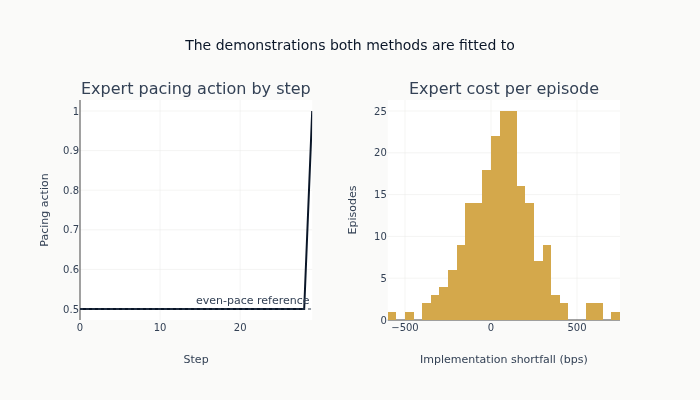

In [9]:
expert_action_matrix = np.vstack([traj["actions"] for traj in expert_data["trajectories"]])
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Expert pacing action by step", "Expert cost per episode"),
    horizontal_spacing=0.14,
)
fig.add_trace(
    go.Scatter(
        x=list(range(expert_action_matrix.shape[1])),
        y=expert_action_matrix.mean(axis=0),
        line=dict(color=COLORS["blue"], width=2),
        showlegend=False,
    ),
    row=1,
    col=1,
)
fig.add_hline(
    y=0.5,
    line=dict(color=COLORS["neutral"], width=1, dash="dot"),
    annotation_text="even-pace reference",
    row=1,
    col=1,
)
fig.add_trace(
    go.Histogram(
        x=expert_shortfalls_bps,
        marker_color=COLORS["amber"],
        showlegend=False,
    ),
    row=1,
    col=2,
)
fig.update_yaxes(title_text="Pacing action", row=1, col=1)
fig.update_xaxes(title_text="Step", row=1, col=1)
fig.update_yaxes(title_text="Episodes", row=1, col=2)
fig.update_xaxes(title_text="Implementation shortfall (bps)", row=1, col=2)
fig.update_layout(
    title="The demonstrations both methods are fitted to",
    height=400,
)
show_plotly_with_alt(
    fig,
    "Two panels describing the expert demonstrations. Left: the mean pacing action at each step, flat at the even-pace reference until the final step, where the conversion returns its maximum. Right: a histogram of the implementation shortfall each demonstration episode produced.",
)

## 2. Behaviour cloning

**Behaviour cloning** is imitation without inference: treat each recorded
state as an input, the action taken there as the target, and fit a regression.
It needs no environment, no reward and no rollouts, which is why it is the
first thing to try and the standard against which inference has to justify its
extra machinery.

Two things it cannot do follow directly from what it is. It produces no
reward, so it can say what the expert did and never why, and it cannot be
transferred to a market where the same objective would imply different
actions. And it is trained on states the expert visited while being asked to
act in states its own errors take it to - a mismatch called **distribution
shift**, whose signature is a clone that fits its held-back demonstrations
closely and degrades once it is driving. Section 5 measures both.

Two clones are fitted, a ridge regression and a small neural network, so the
gap between them says whether the expert's mapping from state to action is
linear.

### Splitting the demonstrations

The split is by whole episode, not by state-action pair. Adjacent states
within one episode differ by one step of inventory and one step of the clock,
so a pair-level split would put near-duplicates of a training row into the
held-back set and report a fit that has seen its own answers.

In [10]:
trajectory_split = int(TRAIN_FRACTION * len(expert_data["trajectories"]))
train_trajectories = expert_data["trajectories"][:trajectory_split]
test_trajectories = expert_data["trajectories"][trajectory_split:]
X_train = np.concatenate([traj["states"] for traj in train_trajectories])
y_train = np.concatenate([traj["actions"] for traj in train_trajectories])
X_test = np.concatenate([traj["states"] for traj in test_trajectories])
y_test = np.concatenate([traj["actions"] for traj in test_trajectories])

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 4800
Test samples: 1200


In [11]:
# Train behavior cloning models (simple and neural network)
print("\nTraining behavior cloning models...")

# Simple linear model
bc_linear = Ridge(alpha=0.1)
bc_linear.fit(X_train, y_train)

# Neural network
bc_nn = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=BC_EPOCHS,
    random_state=SEED,
    early_stopping=True,
    validation_fraction=0.1,
)
bc_nn.fit(X_train, y_train)

# Evaluate
linear_train_mse = np.mean((bc_linear.predict(X_train) - y_train) ** 2)
linear_test_mse = np.mean((bc_linear.predict(X_test) - y_test) ** 2)
nn_train_mse = np.mean((bc_nn.predict(X_train) - y_train) ** 2)
nn_test_mse = np.mean((bc_nn.predict(X_test) - y_test) ** 2)

print("\nBehavior Cloning Results:")
print(f"  Linear - Train MSE: {linear_train_mse:.6f}, Test MSE: {linear_test_mse:.6f}")
print(f"  NN     - Train MSE: {nn_train_mse:.6f}, Test MSE: {nn_test_mse:.6f}")


Training behavior cloning models...



Behavior Cloning Results:
  Linear - Train MSE: 0.007269, Test MSE: 0.007273
  NN     - Train MSE: 0.000001, Test MSE: 0.000001


### Running the clones in the environment

Fitting error on held-back demonstrations is not the quantity of interest.
What matters is what happens when the clone is the one choosing the actions,
because from the first small error onward it is in states the demonstrations
never covered. Every policy in this notebook is run on the same list of
episode seeds, so each seed gives every policy the same market path and the
differences between them can be taken episode by episode.

In [12]:
def evaluate_policy(action_fn, env, episode_seeds: list[int]) -> dict:
    """Evaluate an action function on a fixed list of common episode seeds."""
    shortfalls_bps = []
    action_histories = []

    for episode_seed in episode_seeds:
        obs, _ = env.reset(seed=episode_seed)
        done = False
        actions = []

        while not done:
            action = float(np.clip(action_fn(obs), 0, 1))
            actions.append(action)
            obs, _, terminated, truncated, _ = env.step(np.array([action]))
            done = terminated or truncated

        shortfalls_bps.append(env.total_cost / (env.arrival_price * env.total_shares) * 10_000)
        action_histories.append(actions)

    return {"shortfalls_bps": np.array(shortfalls_bps), "action_histories": action_histories}


# Evaluate BC policies
print("\nEvaluating behavior cloning policies...")
evaluation_seeds = list(range(20_000, 20_000 + N_EVALUATION_EPISODES))
expert_results = evaluate_policy(lambda obs: twap_policy(obs, env), env, evaluation_seeds)
bc_linear_results = evaluate_policy(
    lambda obs: bc_linear.predict(obs.reshape(1, -1))[0], env, evaluation_seeds
)
bc_nn_results = evaluate_policy(
    lambda obs: bc_nn.predict(obs.reshape(1, -1))[0], env, evaluation_seeds
)


def shortfall_bps(result: dict) -> np.ndarray:
    """Per-episode implementation shortfall, in basis points of that episode's arrival notional."""
    return result["shortfalls_bps"]


print("Mean shortfall over the evaluation seeds, in basis points of arrival notional:")
for label, result in [
    ("Expert (TWAP)", expert_results),
    ("BC linear", bc_linear_results),
    ("BC neural net", bc_nn_results),
]:
    print(f"  {label:16s}: {shortfall_bps(result).mean():+7.1f}")


Evaluating behavior cloning policies...


Mean shortfall over the evaluation seeds, in basis points of arrival notional:
  Expert (TWAP)   :   +98.7
  BC linear       :   +98.9
  BC neural net   :   +98.7


## 3. Inferring a reward

Both inference methods below assume the reward is linear in a fixed set of
features of the state and the action,

$$R(s, a) = \mathbf{w}^\top \boldsymbol{\phi}(s, a)$$

so that a trajectory's total reward is $\mathbf{w}^\top \Phi(\tau)$, with
$\Phi(\tau)$ the sum of the feature vector over the trajectory's steps. The
question is how to choose $\mathbf{w}$ so that the demonstrations look like
something a reward-maximiser would produce.

### Maximum entropy

The **maximum-entropy** answer is to make the demonstrations likely under a
distribution over trajectories that is otherwise as uncommitted as possible.
The distribution that maximises entropy subject to matching the expert's
feature counts is exponential in the reward,

$$P(\tau \mid \mathbf{w}) =
\frac{\exp\!\big(\mathbf{w}^\top \Phi(\tau)\big)}{Z(\mathbf{w})},
\qquad Z(\mathbf{w}) = \sum_{\tau' \in \mathcal{T}}
\exp\!\big(\mathbf{w}^\top \Phi(\tau')\big)$$

and its log-likelihood has a gradient with a readable form: the expert's mean
feature count minus the feature count expected under the current
distribution. Weights move to make the expert's trajectories more probable
relative to everything else in $\mathcal{T}$.

$Z(\mathbf{w})$ is the whole difficulty. It sums over every trajectory the
environment admits, and with a continuous action space that set is
uncountable. The implementation here replaces $\mathcal{T}$ with a fixed bank
of trajectories, built once before fitting starts and never rebuilt, so that
the likelihood is a fixed function of the weights and gradient ascent is
climbing a surface that stays still.

### Reading the weights

A positive weight means the expert's trajectories score higher when that
feature is larger, a negative weight the reverse. Two things that reading does
not license: the weights are not comparable across features unless the
features are on the same scale, and a large weight is evidence of association
with the demonstrated behaviour rather than of a preference the demonstrator
holds. Section 6 returns to why the distinction is load-bearing here.

In [13]:
def extract_features(state: np.ndarray, action: float) -> np.ndarray:
    """
    Extract features for linear reward parameterization.

    Features designed to capture execution concerns:
    - inventory_remaining: penalize holding inventory
    - time_pressure: urgency near deadline
    - spread_cost: cost of trading at current spread
    - depth_quality: benefit of trading when liquidity is high
    - action_pace: normalized pace around the reference schedule
    - action_inventory_interaction: trade more when inventory is high

    State: [inventory_ratio, time_ratio, spread, depth, volatility, regime]
    """
    inventory = state[0]
    time_remaining = state[1]
    spread = state[2]
    depth = state[3]
    volatility = state[4]
    regime = state[5]

    # Time pressure increases as deadline approaches
    time_pressure = 1.0 - time_remaining

    return np.array(
        [
            # Core execution features
            inventory,  # 0: remaining inventory (want to reduce)
            time_pressure * inventory,  # 1: urgency-inventory interaction
            spread * action,  # 2: spread cost of trading
            depth * action,  # 3: benefit of trading in deep markets
            action,  # 4: normalized schedule pace
            # Risk features
            volatility * inventory,  # 5: volatility exposure
            regime * inventory,  # 6: stress regime risk
            # Interaction
            action * inventory,  # 7: trade more when inventory high
        ]
    )

### Feature Expectations

Compute the empirical mean of features across all expert trajectories for a
readable baseline. MaxEnt fitting below uses cumulative trajectory feature
counts because the likelihood is defined over complete paths.

In [14]:
def compute_feature_expectations(trajectories: list, extract_fn) -> np.ndarray:
    """Compute empirical feature expectations from trajectories."""
    feature_sums = None
    n_samples = 0

    for traj in trajectories:
        states = traj["states"]
        actions = traj["actions"]

        for state, action in zip(states, actions, strict=False):
            features = extract_fn(state, action)
            if feature_sums is None:
                feature_sums = np.zeros_like(features)
            feature_sums += features
            n_samples += 1

    return feature_sums / n_samples


# Compute expert feature expectations
expert_features = compute_feature_expectations(expert_data["trajectories"], extract_features)
print("Expert Feature Expectations:")
feature_names = [
    "inventory",
    "time_pressure*inv",
    "spread*action",
    "depth*action",
    "action",
    "vol*inventory",
    "regime*inventory",
    "action*inventory",
]
for name, val in zip(feature_names, expert_features, strict=False):
    print(f"  {name:20s}: {val:.4f}")

Expert Feature Expectations:
  inventory           : 0.5164
  time_pressure*inv   : 0.1664
  spread*action       : 0.3163
  depth*action        : 4.5224
  action              : 0.5167
  vol*inventory       : 0.3424
  regime*inventory    : 0.0386
  action*inventory    : 0.2587


### Fixed Trajectory Support

Exact MaxEnt IRL sums over every feasible trajectory. That is intractable in
this continuous environment, so the teaching implementation constructs one
fixed candidate bank before fitting. The bank combines expert paths with
seeded noisy-TWAP, front-loaded, back-loaded, liquidity-sensitive, and random
proposals. Keeping this support fixed is essential: it makes the sampled
partition function and likelihood deterministic.

In [15]:
def proposal_action(obs: np.ndarray, env: ExecutionEnv, kind: int, rng) -> float:
    """Draw an action from one of five weight-independent proposal policies."""
    twap = twap_policy(obs, env)
    if kind == 0:
        action = twap + 0.08 * rng.standard_normal()
    elif kind == 1:
        action = 0.8 + 0.06 * rng.standard_normal()
    elif kind == 2:
        action = (0.2 if obs[1] > 0.4 else 0.8) + 0.06 * rng.standard_normal()
    elif kind == 3:
        action = 0.25 + 0.5 * np.clip(obs[3], 0.0, 1.0)
    else:
        action = rng.beta(2.0, 2.0)
    return float(np.clip(action, 0.0, 1.0))

In [16]:
def sample_candidate_trajectory(env: ExecutionEnv, rng) -> dict:
    """Roll out one trajectory from a randomly chosen proposal policy."""
    kind = int(rng.integers(0, 5))
    obs, _ = env.reset(seed=int(rng.integers(0, 10000)))
    done = False
    traj_states, traj_actions = [], []
    while not done:
        action = proposal_action(obs, env, kind, rng)
        traj_states.append(obs.copy())
        traj_actions.append(action)
        obs, _, terminated, truncated, _ = env.step(np.array([action]))
        done = terminated or truncated
    return {"states": np.array(traj_states), "actions": np.array(traj_actions)}

Each row below is the cumulative feature vector $\Phi(\tau)$ for one complete
trajectory. The candidate bank is generated once and never depends on the
reward weights being estimated.

In [17]:
def trajectory_feature_counts(trajectories: list, extract_features_fn) -> np.ndarray:
    """Return one cumulative feature-count vector per trajectory."""
    return np.vstack(
        [
            np.sum(
                [
                    extract_features_fn(state, action)
                    for state, action in zip(traj["states"], traj["actions"], strict=False)
                ],
                axis=0,
            )
            for traj in trajectories
        ]
    )

The proposal trajectories augment, rather than replace, the training
demonstrations. Including both gives the partition approximation support near
the expert and across deliberately different execution schedules.

In [18]:
def build_candidate_bank(
    expert_trajectories: list,
    env: ExecutionEnv,
    n_candidates: int,
    seed: int,
) -> list:
    """Combine expert paths with a fixed bank of proposal trajectories."""
    rng = np.random.default_rng(seed)
    proposals = [sample_candidate_trajectory(env, rng) for _ in range(n_candidates)]
    return [*expert_trajectories, *proposals]

### MaxEnt Likelihood Optimization

On the fixed support, the partition function is an ordinary stable
log-sum-exp. Gradient ascent therefore optimizes a genuine trajectory
likelihood rather than relabeling a noisy greedy feature-matching loop.

In [19]:
def maxent_distribution(
    candidate_features: np.ndarray,
    weights: np.ndarray,
) -> tuple[np.ndarray, float]:
    """Return stable MaxEnt probabilities and the log-partition value."""
    logits = candidate_features @ weights
    max_logit = logits.max()
    exponentials = np.exp(logits - max_logit)
    return exponentials / exponentials.sum(), float(max_logit + np.log(exponentials.sum()))

Standardizing each trajectory-level feature controls conditioning without
changing the fixed candidate support or the likelihood being optimized.

In [20]:
def prepare_maxent_problem(
    expert_trajectories: list,
    candidate_trajectories: list,
    extract_features_fn,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Standardize trajectory feature counts for MaxEnt optimization."""
    expert_counts = trajectory_feature_counts(expert_trajectories, extract_features_fn)
    candidate_counts = trajectory_feature_counts(candidate_trajectories, extract_features_fn)
    candidate_std = candidate_counts.std(axis=0)
    feature_scale = np.where(candidate_std > 1e-8, candidate_std, 1.0)
    expert_target = (expert_counts / feature_scale).mean(axis=0)
    return expert_counts, candidate_counts / feature_scale, expert_target, feature_scale

The regularized objective combines the expert reward, log-partition term, and
the disclosed L2 penalty used during optimization.

In [21]:
def regularized_log_likelihood(
    expert_target: np.ndarray,
    candidate_features: np.ndarray,
    weights: np.ndarray,
    l2_penalty: float,
) -> float:
    """Evaluate the mean sampled MaxEnt objective."""
    _, log_partition = maxent_distribution(candidate_features, weights)
    likelihood = expert_target @ weights - log_partition
    return float(likelihood - 0.5 * l2_penalty * np.dot(weights, weights))

The optimizer standardizes feature counts for conditioning, applies the exact
finite-support likelihood gradient, and maps coefficients back to the original
feature units for interpretation.

In [22]:
def maxent_irl(
    expert_trajectories: list,
    candidate_trajectories: list,
    extract_features_fn,
    n_iterations: int = 100,
    learning_rate: float = 0.05,
    l2_penalty: float = 0.05,
) -> dict:
    """Fit a linear MaxEnt reward on a fixed sampled trajectory support."""
    problem = prepare_maxent_problem(
        expert_trajectories, candidate_trajectories, extract_features_fn
    )
    expert_counts, candidate_scaled, expert_target, feature_scale = problem
    scaled_weights = np.zeros(expert_target.shape[0])
    history = {"weights": [scaled_weights.copy()], "gradient_norm": [], "log_likelihood": []}

    print(f"Running sampled MaxEnt IRL on {len(candidate_trajectories)} fixed trajectories...")
    for iteration in range(n_iterations):
        probabilities, _ = maxent_distribution(candidate_scaled, scaled_weights)
        model_expectation = probabilities @ candidate_scaled
        gradient = expert_target - model_expectation - l2_penalty * scaled_weights
        step = learning_rate / np.sqrt(1.0 + iteration / 10.0)
        scaled_weights = scaled_weights + step * gradient

        mean_log_likelihood = regularized_log_likelihood(
            expert_target, candidate_scaled, scaled_weights, l2_penalty
        )
        history["weights"].append(scaled_weights.copy())
        history["gradient_norm"].append(np.linalg.norm(gradient))
        history["log_likelihood"].append(float(mean_log_likelihood))
        if (iteration + 1) % 10 == 0 or iteration == 0:
            print(f"  Iteration {iteration + 1:3d}: log likelihood = {mean_log_likelihood:.4f}")

    return {
        "weights": scaled_weights / feature_scale,
        "history": history,
        "expert_features": expert_counts.mean(axis=0),
        "candidate_count": len(candidate_trajectories),
        "feature_scale": feature_scale,
    }

In [23]:
# Fit reward weights using training trajectories only and a fixed candidate bank.
candidate_trajectories = build_candidate_bank(
    expert_trajectories=train_trajectories,
    env=env,
    n_candidates=N_CANDIDATE_TRAJECTORIES,
    seed=SEED + 10_000,
)
irl_result = maxent_irl(
    expert_trajectories=train_trajectories,
    candidate_trajectories=candidate_trajectories,
    extract_features_fn=extract_features,
    n_iterations=IRL_ITERATIONS,
    learning_rate=0.05,
    l2_penalty=MAXENT_L2,
)

Running sampled MaxEnt IRL on 560 fixed trajectories...
  Iteration   1: log likelihood = -6.2966
  Iteration  10: log likelihood = -6.2391
  Iteration  20: log likelihood = -6.2239
  Iteration  30: log likelihood = -6.2140
  Iteration  40: log likelihood = -6.2064
  Iteration  50: log likelihood = -6.2002
  Iteration  60: log likelihood = -6.1950
  Iteration  70: log likelihood = -6.1905
  Iteration  80: log likelihood = -6.1866
  Iteration  90: log likelihood = -6.1831
  Iteration 100: log likelihood = -6.1799


### Feature-Expectation Matching Baseline

The comparison method uses the same update direction,
$\mu_E-\mu_{\pi_k}$, but estimates the policy expectation from fresh
noisy-greedy rollouts under the current weights. It has no partition
function and no trajectory-likelihood objective, so it is feature-expectation
matching rather than MaxEnt IRL.

In [24]:
def best_greedy_action(obs: np.ndarray, weights: np.ndarray, extract_features_fn) -> float:
    """Action in [0.01, 1.0] that maximizes the current linear reward."""
    action_grid = np.linspace(0.01, 1.0, 20)
    rewards = [np.dot(weights, extract_features_fn(obs, action)) for action in action_grid]
    return float(action_grid[int(np.argmax(rewards))])

Fresh rollouts depend on the current reward weights. That distinguishes this
iterative policy-matching procedure from the fixed MaxEnt support above.

In [25]:
def sample_feature_matching_trajectory(
    env: ExecutionEnv,
    weights: np.ndarray,
    extract_features_fn,
    rng,
) -> dict:
    """Roll out one episode under a noisy greedy policy."""
    obs, _ = env.reset(seed=int(rng.integers(0, 10000)))
    done = False
    traj_states, traj_actions = [], []
    while not done:
        greedy = best_greedy_action(obs, weights, extract_features_fn)
        action = float(np.clip(greedy + 0.1 * rng.standard_normal(), 0.01, 1.0))
        traj_states.append(obs.copy())
        traj_actions.append(action)
        obs, _, terminated, truncated, _ = env.step(np.array([action]))
        done = terminated or truncated
    return {"states": np.array(traj_states), "actions": np.array(traj_actions)}

In [26]:
def feature_expectation_irl(
    expert_trajectories: list,
    env: ExecutionEnv,
    extract_features_fn,
    n_iterations: int = 50,
    learning_rate: float = 0.2,
    n_sample_trajectories: int = 50,
    seed: int = 42,
) -> dict:
    """Match expert feature expectations with noisy-greedy policy rollouts."""
    rng = np.random.default_rng(seed)
    expert_features = compute_feature_expectations(expert_trajectories, extract_features_fn)
    weights = np.zeros(len(expert_features))
    history = {"weights": [weights.copy()], "gradient_norm": []}

    print("Running feature-expectation matching...")
    for iteration in range(n_iterations):
        sampled = [
            sample_feature_matching_trajectory(env, weights, extract_features_fn, rng)
            for _ in range(n_sample_trajectories)
        ]
        policy_features = compute_feature_expectations(sampled, extract_features_fn)
        gradient = expert_features - policy_features
        weights = weights + learning_rate * gradient
        history["weights"].append(weights.copy())
        history["gradient_norm"].append(float(np.linalg.norm(gradient)))
        if (iteration + 1) % 10 == 0 or iteration == 0:
            print(
                f"  Iteration {iteration + 1:3d}: "
                f"feature mismatch = {history['gradient_norm'][-1]:.4f}"
            )

    return {"weights": weights, "history": history, "expert_features": expert_features}

In [27]:
feature_match_result = feature_expectation_irl(
    expert_trajectories=train_trajectories,
    env=env,
    extract_features_fn=extract_features,
    n_iterations=FEATURE_MATCH_ITERATIONS,
    learning_rate=0.2,
    n_sample_trajectories=N_FEATURE_MATCH_TRAJECTORIES,
    seed=SEED + 20_000,
)

Running feature-expectation matching...


  Iteration   1: feature mismatch = 4.0759


  Iteration  10: feature mismatch = 4.0899


  Iteration  20: feature mismatch = 4.0599


  Iteration  30: feature mismatch = 4.0654


  Iteration  40: feature mismatch = 4.0770


  Iteration  50: feature mismatch = 4.0529


## 4. The two inferred rewards

Both methods use the same linear features and training demonstrations. Their
different objectives need not recover the same coefficients, especially when
correlated features make the reward non-identifiable.

In [28]:
maxent_weights = irl_result["weights"]
feature_match_weights = feature_match_result["weights"]
maxent_sorted = sorted(
    zip(feature_names, maxent_weights, strict=False), key=lambda x: abs(x[1]), reverse=True
)
feature_match_sorted = sorted(
    zip(feature_names, feature_match_weights, strict=False),
    key=lambda x: abs(x[1]),
    reverse=True,
)
weights_table = pl.DataFrame(
    {
        "feature": feature_names,
        "sampled_maxent": [round(float(weight), 4) for weight in maxent_weights],
        "feature_matching": [round(float(weight), 4) for weight in feature_match_weights],
    }
)
weights_table

feature,sampled_maxent,feature_matching
str,f64,f64
"""inventory""",-0.0887,-0.2639
"""time_pressure*inv""",0.0466,-0.1921
"""spread*action""",-0.0537,-0.0459
"""depth*action""",-0.0036,0.1685
"""action""",-0.092,0.1868
"""vol*inventory""",-0.0189,-0.1813
"""regime*inventory""",0.0109,-0.2592
"""action*inventory""",0.0562,0.4083


These weights are illustrative, **not uniquely identified** structural
estimates of trader preferences. MaxEnt raises demonstration likelihood within
a finite candidate bank; feature matching reduces a rollout-based moment gap.
A large coefficient in either method indicates association with expert
behavior, not necessarily a feature the deterministic TWAP rule uses.

In [29]:
# Visualize reward weight evolution
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Sampled MaxEnt Log Likelihood", "Reward Weights by Method"),
)

# Likelihood plot
fig.add_trace(
    go.Scatter(
        y=irl_result["history"]["log_likelihood"],
        mode="lines",
        name="Mean Log Likelihood",
        line=dict(color=COLORS["blue"]),
    ),
    row=1,
    col=1,
)

_ = fig.add_trace(
    go.Bar(
        x=feature_names,
        y=maxent_weights,
        marker_color=COLORS["blue"],
        name="Sampled MaxEnt",
    ),
    row=1,
    col=2,
)
_ = fig.add_trace(
    go.Bar(
        x=feature_names,
        y=feature_match_weights,
        marker_color=COLORS["amber"],
        name="Feature Matching",
    ),
    row=1,
    col=2,
)

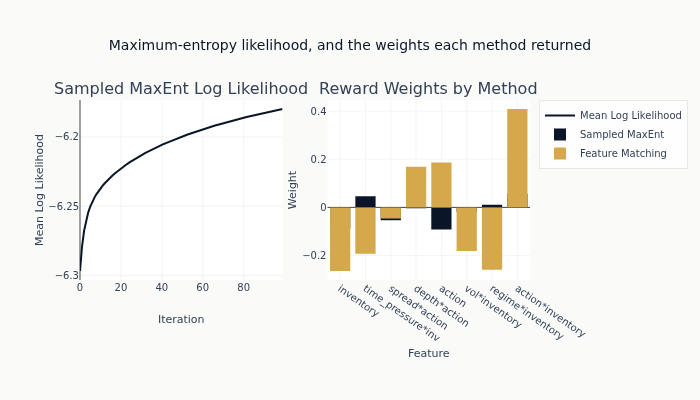

In [30]:
fig.update_layout(
    title="Maximum-entropy likelihood, and the weights each method returned",
    showlegend=True,
    height=400,
    barmode="overlay",
    margin=dict(b=120),
)
fig.update_xaxes(title_text="Iteration", row=1, col=1)
fig.update_xaxes(title_text="Feature", tickangle=35, row=1, col=2)
fig.update_yaxes(title_text="Mean Log Likelihood", row=1, col=1)
fig.update_yaxes(title_text="Weight", row=1, col=2)

show_plotly_with_alt(
    fig,
    "Two panels. Left: the maximum-entropy log likelihood against iteration number. Right: overlaid bars giving each method's inferred weight on each of the eight reward features.",
)

## 5. What the inferred rewards imply as policies

Rather than solving another full dynamic program, MaxEnt uses a one-step
Boltzmann diagnostic policy while feature matching uses its noisy-greedy
policy without evaluation noise. These mappings are diagnostics, not claims
that either procedure recovered an exact soft-optimal policy.

In [31]:
def reward_from_weights(state: np.ndarray, action: float, weights: np.ndarray) -> float:
    """Compute reward using learned weights."""
    features = extract_features(state, action)
    return np.dot(weights, features)

### IRL-Derived Policy Evaluation

Convert each inferred reward into actions and compare both with the expert and
behavior-cloning policies on the same evaluation seeds.

The maximum-entropy fit produces a reward, not a policy: its distribution is
over complete trajectories, and turning that into an action at a single state
would mean solving the control problem the reward defines. The diagnostic
below does something cheaper and separate - it scores a grid of actions at the
current state under the inferred reward, softmaxes those scores at a
temperature chosen here rather than inherited from the fit, and takes the
expectation. A lower temperature concentrates the choice on the
highest-scoring action; a higher one spreads it out. Read what follows as what
the reward prefers one step at a time.

In [32]:
def inferred_boltzmann_action(
    obs: np.ndarray,
    weights: np.ndarray,
    temperature: float = 0.2,
) -> float:
    """Return the expected action under a local Boltzmann distribution."""
    action_grid = np.linspace(0.01, 1.0, 20)
    scores = np.array([reward_from_weights(obs, action, weights) for action in action_grid])
    shifted = (scores - scores.max()) / temperature
    probabilities = np.exp(shifted) / np.exp(shifted).sum()
    return float(probabilities @ action_grid)

In [33]:
def evaluate_reward_policy(
    weights: np.ndarray,
    action_fn,
    env: ExecutionEnv,
    episode_seeds: list[int],
) -> dict:
    """Run one reward-derived policy over the common evaluation seeds."""
    return evaluate_policy(lambda obs: action_fn(obs, weights), env, episode_seeds)

In [34]:
# Evaluate both reward-derived policies.
maxent_policy_results = evaluate_reward_policy(
    maxent_weights,
    inferred_boltzmann_action,
    env,
    evaluation_seeds,
)
feature_match_policy_results = evaluate_reward_policy(
    feature_match_weights,
    lambda obs, weights: best_greedy_action(obs, weights, extract_features),
    env,
    evaluation_seeds,
)

shortfall_by_policy = {
    "Expert (TWAP)": expert_results,
    "BC linear": bc_linear_results,
    "BC neural net": bc_nn_results,
    "MaxEnt-derived": maxent_policy_results,
    "Feature-match-derived": feature_match_policy_results,
}
pl.DataFrame(
    [
        {
            "Policy": name,
            "Mean shortfall (bps)": round(float(shortfall_bps(result).mean()), 2),
            "Std across episodes (bps)": round(float(shortfall_bps(result).std()), 2),
            "Paired gap to expert (bps)": round(
                float((shortfall_bps(result) - shortfall_bps(expert_results)).mean()), 2
            ),
        }
        for name, result in shortfall_by_policy.items()
    ]
)

Policy,Mean shortfall (bps),Std across episodes (bps),Paired gap to expert (bps)
str,f64,f64,f64
"""Expert (TWAP)""",98.71,204.31,0.0
"""BC linear""",98.87,204.77,0.16
"""BC neural net""",98.72,204.39,0.01
"""MaxEnt-derived""",98.65,208.35,-0.06
"""Feature-match-derived""",97.55,171.07,-1.16


### The actions each reward implies

The bars are grouped rather than overlaid because the expert's action
distribution is concentrated: an overlay would bury the two inferred policies
behind it wherever they agree.

In [35]:
maxent_actions = np.concatenate(maxent_policy_results["action_histories"])
feature_match_actions = np.concatenate(feature_match_policy_results["action_histories"])
expert_actions = np.concatenate(expert_results["action_histories"])
bin_edges = np.linspace(0.0, 1.0, 21)

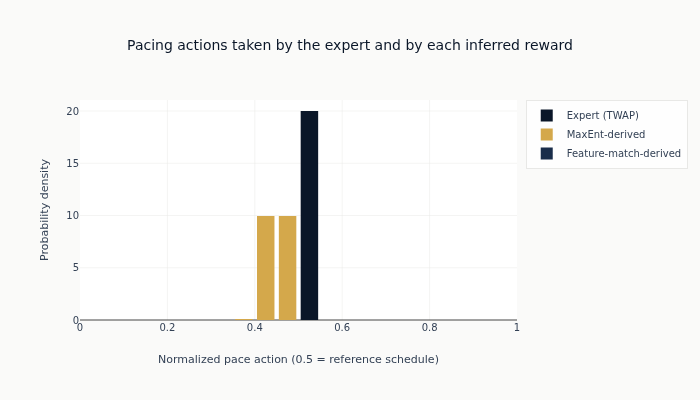

In [36]:
fig = go.Figure()
fig.add_trace(
    go.Histogram(
        x=expert_actions,
        name="Expert (TWAP)",
        marker_color=COLORS["blue"],
        xbins=dict(start=bin_edges[0], end=bin_edges[-1], size=bin_edges[1] - bin_edges[0]),
        histnorm="probability density",
    )
)
fig.add_trace(
    go.Histogram(
        x=maxent_actions,
        name="MaxEnt-derived",
        marker_color=COLORS["amber"],
        xbins=dict(start=bin_edges[0], end=bin_edges[-1], size=bin_edges[1] - bin_edges[0]),
        histnorm="probability density",
    )
)
fig.add_trace(
    go.Histogram(
        x=feature_match_actions,
        name="Feature-match-derived",
        marker_color=COLORS["slate"],
        xbins=dict(start=bin_edges[0], end=bin_edges[-1], size=bin_edges[1] - bin_edges[0]),
        histnorm="probability density",
    )
)

fig.update_layout(
    title="Pacing actions taken by the expert and by each inferred reward",
    xaxis_title="Normalized pace action (0.5 = reference schedule)",
    yaxis_title="Probability density",
    barmode="group",
    height=400,
)
fig.update_xaxes(range=[0.0, 1.0])

show_plotly_with_alt(
    fig,
    "Grouped, normalised histograms of the pacing actions taken by the expert and by each of the two reward-derived policies, over the pace range from zero to one.",
)

### Cost of every policy on the same episodes

The table above gives each policy's mean and dispersion; the figure gives the
whole distribution, which is what decides whether two means are far apart.

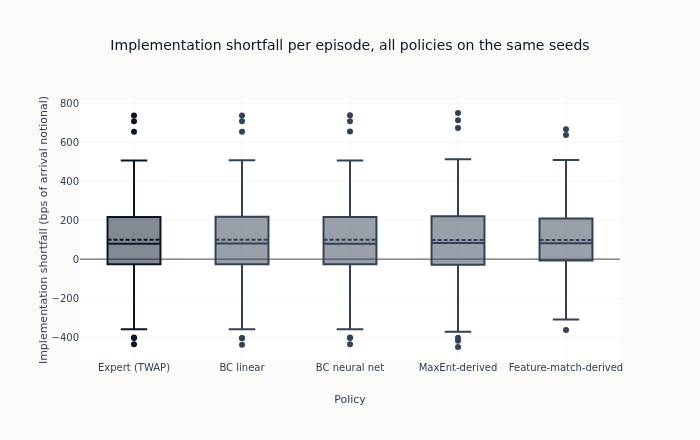

In [37]:
fig = go.Figure()
for name, result in shortfall_by_policy.items():
    fig.add_trace(
        go.Box(
            y=shortfall_bps(result),
            name=name,
            boxmean=True,
            marker_color=COLORS["blue"] if name == "Expert (TWAP)" else COLORS["neutral"],
            showlegend=False,
        )
    )
fig.update_layout(
    title="Implementation shortfall per episode, all policies on the same seeds",
    xaxis_title="Policy",
    yaxis_title="Implementation shortfall (bps of arrival notional)",
    height=440,
)
show_plotly_with_alt(
    fig,
    "A box per policy over the per-episode implementation shortfall in basis points, the expert drawn darker than the four fitted policies.",
)

## 6. Key takeaways

### The three methods, side by side

| | Behaviour cloning | Feature matching | Sampled maximum entropy |
|---|---|---|---|
| **Fits** | a policy $\pi(a \mid s)$ | a reward $R(s,a)$ | a reward $R(s,a)$ |
| **By** | supervised regression | matching rollout feature means | maximising a trajectory likelihood |
| **Normalisation** | none | none | a partition function over a fixed bank |
| **Answers** | what the expert did | what the expert's actions covary with | what the expert's actions covary with |
| **Fails by** | error compounding once it drives the environment | cycling, with no objective it is descending | approximating the support, and non-identifiability |

The middle column is the one to notice. Feature matching updates the weights
by the gap between expert and rollout feature means, which looks like a
gradient and is not one: there is no scalar objective it is the gradient of,
so the iteration can cycle and its stopping point is where the budget ran out.
The maximum-entropy fit adds the partition function, which is exactly what
turns the same update direction into the gradient of a likelihood - and the
cost of that is that the likelihood is over the bank of trajectories the
partition sums, not over the environment.

Each policy is compared with the expert by the per-episode difference in its
shortfall, not by the ratio of the two means. The mean shortfall over these
episodes is dominated by where the price happened to go, so it is a small
number with a large standard error and can sit either side of zero; a ratio
built on it would move with the denominator's noise rather than with the
policies.

The difference is taken within an episode, which matches the market shocks the
two policies faced. It does not net the price out of the comparison: the
policies sell different quantities at different steps, so the difference
retains the price movement weighted by those quantity differences, and the
environment's permanent impact depends on what each policy traded. What the
paired figure measures is one schedule against another on matched markets,
timing and impact included.

In [38]:
def gap_to_expert(name: str, result: dict) -> str:
    """One line comparing a policy with the expert, paired by evaluation seed."""
    difference = shortfall_bps(result) - shortfall_bps(expert_results)
    standard_error = float(difference.std(ddof=1) / np.sqrt(difference.size))
    return (
        f"- **{name}**: {difference.mean():+.2f} bps per episode against the expert, where a "
        f"positive number is the more expensive policy. Standard error {standard_error:.2f}, so "
        f"a gap of {abs(difference.mean()) / standard_error:.1f} standard errors."
    )


gap_lines = "\n".join(
    gap_to_expert(name, result)
    for name, result in [
        ("BC linear", bc_linear_results),
        ("BC neural net", bc_nn_results),
        ("MaxEnt-derived", maxent_policy_results),
        ("Feature-match-derived", feature_match_policy_results),
    ]
)
maxent_top_feature, maxent_top_weight = maxent_sorted[0]
feature_top_feature, feature_top_weight = feature_match_sorted[0]
display(
    Markdown(f"""
**Every fitted policy lands within a couple of standard errors of the expert on cost.** Against
it, on {N_EVALUATION_EPISODES} paired episodes:

{gap_lines}

That is a comparison of costs and nothing more. In particular it does not show that the clones
stayed inside the states the demonstrations covered. A clone that predicts a slightly different
pace trades a slightly different quantity, which moves the inventory its next observation
reports, so it can leave the demonstrated distribution however small the cost gap turns out to
be; showing that it did not would take a measurement of state coverage, and this notebook does
not make one. What can be said about the demonstrator is that it is nearly constant - the
reference pace at every step, the conversion's maximum on the last - which leaves a clone
little to get wrong and these columns little to separate.

**An inferred reward is a statement about covariance, not about preference.** The
maximum-entropy fit puts its largest coefficient on **{maxent_top_feature}**
({maxent_top_weight:+.3f}) and feature matching on **{feature_top_feature}**
({feature_top_weight:+.3f}), from the same demonstrations, under the same features, describing
the same behaviour. Two objectives disagreeing about which feature carries the explanation is
the normal case for a linear reward over correlated features, and it is what
non-identifiability looks like in practice. The test worth applying to any such weight is
whether the demonstrator could have read the feature at all: TWAP reads neither the depth nor
the volatility the observation reports, so a large weight on either would have been a
correlate rather than a preference.

**Check what an optimiser is descending before reading its stopping point.** The
maximum-entropy log likelihood moves from {irl_result["history"]["log_likelihood"][0]:.3f} to
{irl_result["history"]["log_likelihood"][-1]:.3f} over its iterations, which is a number that
means something because there is an objective. Feature matching ends with a residual moment gap
of {feature_match_result["history"]["gradient_norm"][-1]:.3f}, which is not a value it was
minimising, and a smaller one would not have meant a better fit.

**Matching a cost is not recovering a policy.** Both reward-derived policies sit close to the
expert on cost, which here is a low bar: an episode's shortfall is mostly what the price did
over it, and any schedule that trades steadily pays a similar amount. Whether either recovered
the expert's *behaviour* is the action-distribution figure in section 5, not the cost column,
and the two rewards behind those policies disagree about which feature explains the
demonstrations at all.

### Known limitations

- Exact maximum-entropy inference normalises over every trajectory the environment admits. This
  implementation normalises over {N_CANDIDATE_TRAJECTORIES} proposals plus the training
  demonstrations, so the likelihood is over that bank. Widening the bank changes the estimate.
- The reward is linear in eight hand-chosen features. A reward the expert actually optimises but
  that is not in that span cannot be recovered, and several of the eight are strongly correlated
  along the expert's own paths, so the coefficients are not separately identified.
- The diagnostic policies are one-step mappings from the inferred reward, not solutions of the
  control problem it defines. They say what the reward prefers locally, not what an agent
  trained on it would do.
- One demonstrator, one environment, one seed. The comparison between the two inference
  procedures is an illustration of how they differ, not a measurement of which recovers more.
- Absolute shortfall over these episodes is dominated by the realised price path rather than by
  the schedule. Only the paired differences above are informative about the policies; the level
  is not.

**Next**: `07_backtest_with_impact` leaves inference aside and asks what market impact does to a
strategy's reported performance when the backtest stops assuming fills are free.
""")
)


**Every fitted policy lands within a couple of standard errors of the expert on cost.** Against
it, on 200 paired episodes:

- **BC linear**: +0.16 bps per episode against the expert, where a positive number is the more expensive policy. Standard error 0.09, so a gap of 1.7 standard errors.
- **BC neural net**: +0.01 bps per episode against the expert, where a positive number is the more expensive policy. Standard error 0.01, so a gap of 1.5 standard errors.
- **MaxEnt-derived**: -0.06 bps per episode against the expert, where a positive number is the more expensive policy. Standard error 0.39, so a gap of 0.2 standard errors.
- **Feature-match-derived**: -1.16 bps per episode against the expert, where a positive number is the more expensive policy. Standard error 3.15, so a gap of 0.4 standard errors.

That is a comparison of costs and nothing more. In particular it does not show that the clones
stayed inside the states the demonstrations covered. A clone that predicts a slightly different
pace trades a slightly different quantity, which moves the inventory its next observation
reports, so it can leave the demonstrated distribution however small the cost gap turns out to
be; showing that it did not would take a measurement of state coverage, and this notebook does
not make one. What can be said about the demonstrator is that it is nearly constant - the
reference pace at every step, the conversion's maximum on the last - which leaves a clone
little to get wrong and these columns little to separate.

**An inferred reward is a statement about covariance, not about preference.** The
maximum-entropy fit puts its largest coefficient on **action**
(-0.092) and feature matching on **action*inventory**
(+0.408), from the same demonstrations, under the same features, describing
the same behaviour. Two objectives disagreeing about which feature carries the explanation is
the normal case for a linear reward over correlated features, and it is what
non-identifiability looks like in practice. The test worth applying to any such weight is
whether the demonstrator could have read the feature at all: TWAP reads neither the depth nor
the volatility the observation reports, so a large weight on either would have been a
correlate rather than a preference.

**Check what an optimiser is descending before reading its stopping point.** The
maximum-entropy log likelihood moves from -6.297 to
-6.180 over its iterations, which is a number that
means something because there is an objective. Feature matching ends with a residual moment gap
of 4.053, which is not a value it was
minimising, and a smaller one would not have meant a better fit.

**Matching a cost is not recovering a policy.** Both reward-derived policies sit close to the
expert on cost, which here is a low bar: an episode's shortfall is mostly what the price did
over it, and any schedule that trades steadily pays a similar amount. Whether either recovered
the expert's *behaviour* is the action-distribution figure in section 5, not the cost column,
and the two rewards behind those policies disagree about which feature explains the
demonstrations at all.

### Known limitations

- Exact maximum-entropy inference normalises over every trajectory the environment admits. This
  implementation normalises over 400 proposals plus the training
  demonstrations, so the likelihood is over that bank. Widening the bank changes the estimate.
- The reward is linear in eight hand-chosen features. A reward the expert actually optimises but
  that is not in that span cannot be recovered, and several of the eight are strongly correlated
  along the expert's own paths, so the coefficients are not separately identified.
- The diagnostic policies are one-step mappings from the inferred reward, not solutions of the
  control problem it defines. They say what the reward prefers locally, not what an agent
  trained on it would do.
- One demonstrator, one environment, one seed. The comparison between the two inference
  procedures is an illustration of how they differ, not a measurement of which recovers more.
- Absolute shortfall over these episodes is dominated by the realised price path rather than by
  the schedule. Only the paired differences above are informative about the policies; the level
  is not.

**Next**: `07_backtest_with_impact` leaves inference aside and asks what market impact does to a
strategy's reported performance when the backtest stops assuming fills are free.
